## TUGAS PEMROGRAMAN PARALEL 2

#### Nama           : Naila Faiza Inshyra
#### NIM            : 2411512013
#### Kelas          : Pemorograman Paralel A
#### Jurusan        : Teknik Komputer
#### Dosen Pengampu : Ibu Desta Yolanda

### SOAL NOMOR 1

In [14]:
#JAWABAN NOMOR 1:
import threading
import time

# --- Versi TANPA lock ---
saldo = 1_000_000

def transaksi(jumlah_operasi):
    global saldo
    for _ in range(jumlah_operasi):
        # tarik 1 -- dipecah eksplisit (baca -> jeda -> tulis) supaya celah race
        # lebih lebar dan mudah teramati, sama seperti pola demo counter di Pertemuan 5
        temp = saldo
        time.sleep(0)      # menyerahkan giliran ke thread lain (context switch)
        saldo = temp - 1

        # setor 1 -- pola yang sama
        temp = saldo
        time.sleep(0)
        saldo = temp + 1

JUMLAH_OPERASI = 10_000
JUMLAH_THREAD = 10

saldo = 1_000_000
start = time.perf_counter()
threads = [threading.Thread(target=transaksi, args=(JUMLAH_OPERASI,)) for _ in range(JUMLAH_THREAD)]
for t in threads:
    t.start()
for t in threads:
    t.join()
waktu_tanpa_lock = time.perf_counter() - start

print(f"Saldo awal                 : 1,000,000")
print(f"Saldo akhir (TANPA lock)   : {saldo:,}")
print(f"Selisih dari saldo awal    : {saldo - 1_000_000:,}")
print(f"Waktu eksekusi             : {waktu_tanpa_lock:.4f} detik")

Saldo awal                 : 1,000,000
Saldo akhir (TANPA lock)   : 999,998
Selisih dari saldo awal    : -2
Waktu eksekusi             : 0.3394 detik


In [15]:
#JAWABAN NOMOR 1:
# --- Versi DENGAN threading.Lock() ---
saldo = 1_000_000
lock_saldo = threading.Lock()

def transaksi_aman(jumlah_operasi):
    global saldo
    for _ in range(jumlah_operasi):
        with lock_saldo:      # <-- critical section dimulai: tarik + setor jadi 1 blok atomik
            temp = saldo
            time.sleep(0)
            saldo = temp - 1
            temp = saldo
            time.sleep(0)
            saldo = temp + 1
                              # <-- lock otomatis dilepas di sini

saldo = 1_000_000
start = time.perf_counter()
threads = [threading.Thread(target=transaksi_aman, args=(JUMLAH_OPERASI,)) for _ in range(JUMLAH_THREAD)]
for t in threads:
    t.start()
for t in threads:
    t.join()
waktu_dengan_lock = time.perf_counter() - start

print(f"Saldo awal                  : 1,000,000")
print(f"Saldo akhir (DENGAN lock)   : {saldo:,}")
print(f"Sesuai?                     : {'✅ YA' if saldo == 1_000_000 else '❌ TIDAK'}")
print(f"Waktu eksekusi              : {waktu_dengan_lock:.4f} detik")
print()
print(f"Perbandingan waktu -> tanpa lock: {waktu_tanpa_lock:.4f}s | dengan lock: {waktu_dengan_lock:.4f}s")

Saldo awal                  : 1,000,000
Saldo akhir (DENGAN lock)   : 1,000,000
Sesuai?                     : ✅ YA
Waktu eksekusi              : 0.6869 detik

Perbandingan waktu -> tanpa lock: 0.3394s | dengan lock: 0.6869s


### SOAL NOMOR 2

In [16]:
#JAWABAN NOMOR 2:
import threading
import queue
import time
import random

def producer(q, jumlah_item, jumlah_consumer, nama="Producer"):
    for i in range(jumlah_item):
        item = f"item-{i}"
        time.sleep(random.uniform(0.02, 0.08))   # simulasi waktu produksi
        q.put(item)
        print(f"[{nama}] menghasilkan: {item}")
    # Kirim SATU sinyal None untuk SETIAP consumer, agar ketiganya
    # sama-sama menerima sinyal berhenti (bukan hanya diteruskan berantai).
    for _ in range(jumlah_consumer):
        q.put(None)

def consumer(q, nama="Consumer"):
    total_diproses = 0
    while True:
        item = q.get()
        if item is None:
            # Sinyal berhenti diterima langsung dari producer -> tidak perlu
            # diteruskan lagi karena producer sudah mengirim sinyal untuk semua consumer.
            q.task_done()
            break
        time.sleep(random.uniform(0.03, 0.1))    # simulasi waktu pemrosesan
        print(f"    [{nama}] memproses: {item}")
        total_diproses += 1
        q.task_done()
    print(f"    [{nama}] berhenti. Total item diproses: {total_diproses}")

JUMLAH_ITEM = 15
JUMLAH_CONSUMER = 3

q = queue.Queue()

t_producer = threading.Thread(target=producer, args=(q, JUMLAH_ITEM, JUMLAH_CONSUMER))
t_consumers = [
    threading.Thread(target=consumer, args=(q,), kwargs={"nama": f"Consumer-{i+1}"})
    for i in range(JUMLAH_CONSUMER)
]

start = time.perf_counter()
t_producer.start()
for t in t_consumers:
    t.start()

t_producer.join()
for t in t_consumers:
    t.join()
waktu = time.perf_counter() - start

print(f"\nSemua item sudah diproduksi dan dikonsumsi oleh {JUMLAH_CONSUMER} consumer.")
print(f"Total waktu eksekusi: {waktu:.2f} detik")

[Producer] menghasilkan: item-0
[Producer] menghasilkan: item-1
    [Consumer-1] memproses: item-0
[Producer] menghasilkan: item-2
    [Consumer-2] memproses: item-1
[Producer] menghasilkan: item-3
    [Consumer-3] memproses: item-2
    [Consumer-1] memproses: item-3
[Producer] menghasilkan: item-4
    [Consumer-2] memproses: item-4
[Producer] menghasilkan: item-5
    [Consumer-3] memproses: item-5
[Producer] menghasilkan: item-6
[Producer] menghasilkan: item-7
    [Consumer-1] memproses: item-6
[Producer] menghasilkan: item-8
    [Consumer-2] memproses: item-7
[Producer] menghasilkan: item-9
    [Consumer-3] memproses: item-8
[Producer] menghasilkan: item-10
    [Consumer-1] memproses: item-9
[Producer] menghasilkan: item-11
    [Consumer-2] memproses: item-10
[Producer] menghasilkan: item-12
    [Consumer-3] memproses: item-11
[Producer] menghasilkan: item-13
    [Consumer-1] memproses: item-12
    [Consumer-2] memproses: item-13
[Producer] menghasilkan: item-14
    [Consumer-1] berh

### SOAL NOMOR 3

In [17]:
#JAWABAN NOMOR 3:
import time
import random
from concurrent.futures import ThreadPoolExecutor, as_completed

# Simulasi 50 "file" dengan ukuran/latensi berbeda-beda (dalam detik)
random.seed(42)
daftar_file = [f"file_{i}.dat" for i in range(50)]
latensi_simulasi = {f: random.uniform(0.05, 0.15) for f in daftar_file}

def download_file(nama_file):
    # Simulasi mengunduh satu file dari jaringan (I/O-bound)
    durasi = latensi_simulasi[nama_file]
    time.sleep(durasi)  # <-- di dunia nyata, ini akan digantikan requests.get(url)
    ukuran_kb = round(durasi * 1000)  # ukuran fiktif, sekadar untuk laporan
    return f"{nama_file} ({ukuran_kb} KB)"

def jalankan_dengan_pool(max_workers):
    start = time.perf_counter()
    hasil_pool = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_ke_file = {executor.submit(download_file, f): f for f in daftar_file}
        for future in as_completed(future_ke_file):
            hasil_pool.append(future.result())
    return time.perf_counter() - start

daftar_max_workers = [2, 4, 8, 16]
hasil_waktu = {}

for mw in daftar_max_workers:
    waktu = jalankan_dengan_pool(mw)
    hasil_waktu[mw] = waktu
    print(f"max_workers = {mw:>2} -> waktu eksekusi: {waktu:.3f} detik")

print("\nRingkasan:")
for mw, w in hasil_waktu.items():
    print(f"  max_workers={mw:<3}: {w:.3f} detik")

max_workers =  2 -> waktu eksekusi: 2.413 detik
max_workers =  4 -> waktu eksekusi: 1.236 detik
max_workers =  8 -> waktu eksekusi: 0.658 detik
max_workers = 16 -> waktu eksekusi: 0.364 detik

Ringkasan:
  max_workers=2  : 2.413 detik
  max_workers=4  : 1.236 detik
  max_workers=8  : 0.658 detik
  max_workers=16 : 0.364 detik


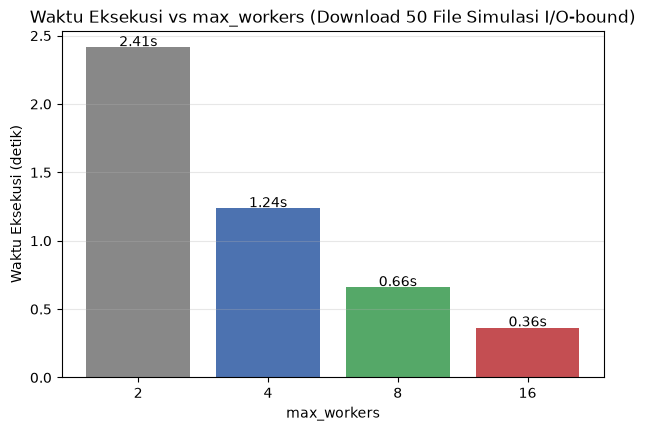

In [18]:
#JAWABAN NOMOR 3:
import matplotlib.pyplot as plt

max_workers_list = list(hasil_waktu.keys())
waktu_list = list(hasil_waktu.values())

plt.figure(figsize=(7, 4.5))
bars = plt.bar([str(mw) for mw in max_workers_list], waktu_list,
               color=["#888888", "#4C72B0", "#55A868", "#C44E52"])
plt.xlabel("max_workers")
plt.ylabel("Waktu Eksekusi (detik)")
plt.title(f"Waktu Eksekusi vs max_workers (Download {len(daftar_file)} File Simulasi I/O-bound)")
for b, w in zip(bars, waktu_list):
    plt.text(b.get_x() + b.get_width()/2, w + 0.01, f"{w:.2f}s", ha='center')
plt.grid(axis='y', alpha=0.3)
plt.show()

### SOAL NOMOR 4